In [2]:
# ============================================================
# ROVER V3 — CELL 1
# ENVIRONMENT + CONFIGURATION
# ============================================================

import os
import gc
import random
import numpy as np
import torch

from google.colab import drive

drive.mount("/content/drive")

# ------------------------------------------------------------
# Device
# ------------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 60)
print("ROVER V3 — ENVIRONMENT")
print("=" * 60)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU memory:",
          round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
          "GB")

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ------------------------------------------------------------
# Rover configuration
# ------------------------------------------------------------

NUM_CLASSES = 10

INPUT_W = 476
INPUT_H = 266

BATCH_SIZE = 8
NUM_WORKERS = 0

EPOCHS = 30

LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

FOCAL_GAMMA = 2.0

print()
print("Classes:", NUM_CLASSES)
print("Input:", INPUT_W, "x", INPUT_H)
print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)
print("Learning rate:", LEARNING_RATE)

print("=" * 60)
print("✅ CONFIGURATION READY")
print("=" * 60)

Mounted at /content/drive
ROVER V3 — ENVIRONMENT
Device: cuda
GPU: Tesla T4
GPU memory: 14.56 GB

Classes: 10
Input: 476 x 266
Batch size: 8
Epochs: 30
Learning rate: 0.001
✅ CONFIGURATION READY


In [3]:
# ============================================================
# ROVER V3 — CELL 2
# DATASET PATHS
# ============================================================

DATASET_ZIP = (
    "/content/drive/MyDrive/Rover_Project/"
    "Offroad_Segmentation_Training_Dataset.zip"
)

EXTRACT_ROOT = "/content/rover_training"

DATASET_ROOT = os.path.join(
    EXTRACT_ROOT,
    "Offroad_Segmentation_Training_Dataset"
)

TRAIN_DIR = os.path.join(DATASET_ROOT, "train")
VAL_DIR = os.path.join(DATASET_ROOT, "val")

print("=" * 60)
print("ROVER V3 — DATASET")
print("=" * 60)

print("ZIP:", DATASET_ZIP)
print("Train:", TRAIN_DIR)
print("Val  :", VAL_DIR)

print("=" * 60)

ROVER V3 — DATASET
ZIP: /content/drive/MyDrive/Rover_Project/Offroad_Segmentation_Training_Dataset.zip
Train: /content/rover_training/Offroad_Segmentation_Training_Dataset/train
Val  : /content/rover_training/Offroad_Segmentation_Training_Dataset/val


In [5]:
# ============================================================
# ROVER V3 — CELL 3
# EXTRACT DATASET
# ============================================================

import zipfile

if os.path.exists(TRAIN_DIR) and os.path.exists(VAL_DIR):
    print("✅ Dataset already extracted")
    print("Skipping extraction.")
else:
    print("Extracting dataset...")

    os.makedirs(EXTRACT_ROOT, exist_ok=True)

    with zipfile.ZipFile(DATASET_ZIP, "r") as z:
        z.extractall(EXTRACT_ROOT)

    print("✅ Extraction complete")

print()
print("Train exists:", os.path.exists(TRAIN_DIR))
print("Val exists  :", os.path.exists(VAL_DIR))

Extracting dataset...
✅ Extraction complete

Train exists: True
Val exists  : True


In [6]:
# ============================================================
# ROVER V3 — CELL 4
# DATASET + MASK CONVERSION
# ============================================================

from PIL import Image

from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

# ------------------------------------------------------------
# Exact Falcon raw-value mapping
# ------------------------------------------------------------

VALUE_MAP = {
    0:     0,   # Background
    100:   1,   # Trees
    200:   2,   # Lush Bushes
    300:   3,   # Dry Grass
    500:   4,   # Dry Bushes
    550:   5,   # Ground Clutter
    700:   6,   # Logs
    800:   7,   # Rocks
    7100:  8,   # Landscape
    10000: 9    # Sky
}

CLASS_NAMES = [
    "Background",
    "Trees",
    "Lush Bushes",
    "Dry Grass",
    "Dry Bushes",
    "Ground Clutter",
    "Logs",
    "Rocks",
    "Landscape",
    "Sky"
]

def convert_mask(mask):
    arr = np.array(mask)

    new_arr = np.zeros_like(arr, dtype=np.uint8)

    for raw_value, class_id in VALUE_MAP.items():
        new_arr[arr == raw_value] = class_id

    return Image.fromarray(new_arr)


class RoverDataset(Dataset):

    def __init__(self, data_dir):

        self.image_dir = os.path.join(
            data_dir, "Color_Images"
        )

        self.mask_dir = os.path.join(
            data_dir, "Segmentation"
        )

        self.ids = sorted([
            f for f in os.listdir(self.image_dir)
            if f.lower().endswith(".png")
        ])

        self.image_transform = transforms.Compose([
            transforms.Resize(
                (INPUT_H, INPUT_W),
                interpolation=transforms.InterpolationMode.BILINEAR
            ),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])

        self.mask_transform = transforms.Compose([
            transforms.Resize(
                (INPUT_H, INPUT_W),
                interpolation=transforms.InterpolationMode.NEAREST
            ),
            transforms.PILToTensor()
        ])

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):

        filename = self.ids[idx]

        image_path = os.path.join(
            self.image_dir, filename
        )

        mask_path = os.path.join(
            self.mask_dir, filename
        )

        image = Image.open(image_path).convert("RGB")
        mask = Image.open(mask_path)

        mask = convert_mask(mask)

        image = self.image_transform(image)

        mask = self.mask_transform(mask).squeeze(0).long()

        return image, mask, filename


train_dataset = RoverDataset(TRAIN_DIR)
val_dataset = RoverDataset(VAL_DIR)

print("=" * 60)
print("ROVER V3 — DATASET")
print("=" * 60)

print("Train:", len(train_dataset))
print("Val  :", len(val_dataset))

print("=" * 60)
print("✅ DATASET READY")
print("=" * 60)

ROVER V3 — DATASET
Train: 2857
Val  : 317
✅ DATASET READY


In [7]:
# ============================================================
# ROVER V3 — CELL 5
# DATALOADERS
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("=" * 60)
print("ROVER V3 — DATALOADERS")
print("=" * 60)

print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))
print("Workers      :", NUM_WORKERS)

print("=" * 60)
print("✅ DATALOADERS READY")
print("=" * 60)

ROVER V3 — DATALOADERS
Train batches: 358
Val batches  : 40
Workers      : 0
✅ DATALOADERS READY


In [8]:
# ============================================================
# ROVER V3 — CELL 6
# BATCH VERIFICATION
# ============================================================

images, masks, filenames = next(iter(train_loader))

print("=" * 60)
print("ROVER V3 — BATCH TEST")
print("=" * 60)

print("Images:", images.shape)
print("Masks :", masks.shape)

print("Image dtype:", images.dtype)
print("Mask dtype :", masks.dtype)

print("Mask classes:",
      torch.unique(masks).tolist())

print("First files:", filenames[:5])

assert images.shape[1:] == (3, INPUT_H, INPUT_W)
assert masks.shape[1:] == (INPUT_H, INPUT_W)

print()
print("✅ BATCH PIPELINE VERIFIED")
print("=" * 60)

ROVER V3 — BATCH TEST
Images: torch.Size([8, 3, 266, 476])
Masks : torch.Size([8, 266, 476])
Image dtype: torch.float32
Mask dtype : torch.int64
Mask classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
First files: ('ww10000129.png', 'w0000176.png', 'w0000188.png', 'cc0000140.png', 'cc0000853.png')

✅ BATCH PIPELINE VERIFIED


In [9]:
# ============================================================
# ROVER V3 — CELL 7
# EVIDENCE-BASED CLASS WEIGHTS
# ============================================================

CLASS_WEIGHTS = torch.tensor([
    0.7402,  # Background
    0.6599,  # Trees
    0.5092,  # Lush Bushes
    0.2856,  # Dry Grass
    1.1835,  # Dry Bushes
    0.5917,  # Ground Clutter
    4.4437,  # Logs
    1.1333,  # Rocks
    0.2509,  # Landscape
    0.2022   # Sky
], dtype=torch.float32).to(device)

print("=" * 60)
print("ROVER V3 — CLASS WEIGHTS")
print("=" * 60)

for i, (name, weight) in enumerate(
    zip(CLASS_NAMES, CLASS_WEIGHTS)
):
    print(
        f"{i}: {name:<18} {weight.item():.4f}"
    )

print()
print("Mean:", CLASS_WEIGHTS.mean().item())
print("Min :", CLASS_WEIGHTS.min().item())
print("Max :", CLASS_WEIGHTS.max().item())

print("=" * 60)
print("✅ WEIGHTS READY")
print("=" * 60)

ROVER V3 — CLASS WEIGHTS
0: Background         0.7402
1: Trees              0.6599
2: Lush Bushes        0.5092
3: Dry Grass          0.2856
4: Dry Bushes         1.1835
5: Ground Clutter     0.5917
6: Logs               4.4437
7: Rocks              1.1333
8: Landscape          0.2509
9: Sky                0.2022

Mean: 1.0000200271606445
Min : 0.2021999955177307
Max : 4.443699836730957
✅ WEIGHTS READY


In [10]:
# ============================================================
# ROVER V3 — CELL 8
# WEIGHTED CE + WEIGHTED FOCAL LOSS
# ============================================================

import torch.nn as nn
import torch.nn.functional as F

# ------------------------------------------------------------
# Weighted Cross Entropy
# ------------------------------------------------------------

weighted_ce_loss = nn.CrossEntropyLoss(
    weight=CLASS_WEIGHTS
)


# ------------------------------------------------------------
# Weighted Focal Loss
# ------------------------------------------------------------

class WeightedFocalLoss(nn.Module):

    def __init__(
        self,
        weight=None,
        gamma=2.0
    ):
        super().__init__()

        self.weight = weight
        self.gamma = gamma

    def forward(self, logits, targets):

        ce = F.cross_entropy(
            logits,
            targets,
            weight=self.weight,
            reduction="none"
        )

        pt = torch.exp(-ce)

        focal = (
            (1.0 - pt) ** self.gamma
        ) * ce

        return focal.mean()


focal_loss = WeightedFocalLoss(
    weight=CLASS_WEIGHTS,
    gamma=FOCAL_GAMMA
)


# ------------------------------------------------------------
# Combined loss
# ------------------------------------------------------------

def combined_loss(logits, targets):

    ce = weighted_ce_loss(
        logits,
        targets
    )

    focal = focal_loss(
        logits,
        targets
    )

    total = (
        0.5 * ce +
        0.5 * focal
    )

    return total, ce, focal


print("=" * 60)
print("ROVER V3 — LOSS")
print("=" * 60)

print("Weighted CE : 0.50")
print("Focal       : 0.50")
print("Gamma       :", FOCAL_GAMMA)

print()
print("Formula:")
print("Loss = 0.5 × WeightedCE + 0.5 × WeightedFocal")

print("=" * 60)
print("✅ LOSS READY")
print("=" * 60)

ROVER V3 — LOSS
Weighted CE : 0.50
Focal       : 0.50
Gamma       : 2.0

Formula:
Loss = 0.5 × WeightedCE + 0.5 × WeightedFocal
✅ LOSS READY


In [11]:
# ============================================================
# ROVER V3 — CELL 9
# DINOv2 ViT-S/14
# ============================================================

print("=" * 60)
print("ROVER V3 — LOADING DINOv2 ViT-S/14")
print("=" * 60)

dino = torch.hub.load(
    "facebookresearch/dinov2",
    "dinov2_vits14"
)

dino = dino.to(device)
dino.eval()

for param in dino.parameters():
    param.requires_grad = False

print("✅ DINOv2 loaded")

# ------------------------------------------------------------
# Verify embedding dimension
# ------------------------------------------------------------

with torch.no_grad():

    sample_images = images[:2].to(
        device,
        non_blocking=True
    )

    features = dino.forward_features(
        sample_images
    )["x_norm_patchtokens"]

EMBED_DIM = features.shape[-1]

print("Embedding dimension:", EMBED_DIM)
print("Patch features:", features.shape)

del sample_images, features
torch.cuda.empty_cache()
gc.collect()

print("=" * 60)
print("✅ DINOv2 READY")
print("=" * 60)

ROVER V3 — LOADING DINOv2 ViT-S/14
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [00:00<00:00, 403MB/s]


✅ DINOv2 loaded
Embedding dimension: 384
Patch features: torch.Size([2, 646, 384])
✅ DINOv2 READY


In [12]:
# ============================================================
# ROVER V3 — CELL 10
# SEGMENTATION HEAD
# ============================================================

class RoverSegHead(nn.Module):

    def __init__(
        self,
        in_channels=384,
        num_classes=10,
        token_h=19,
        token_w=34
    ):

        super().__init__()

        self.token_h = token_h
        self.token_w = token_w

        self.conv1 = nn.Conv2d(
            in_channels,
            128,
            kernel_size=3,
            padding=1
        )

        self.conv2 = nn.Conv2d(
            128,
            128,
            kernel_size=3,
            padding=1
        )

        self.classifier = nn.Conv2d(
            128,
            num_classes,
            kernel_size=1
        )

        self.activation = nn.GELU()

    def forward(self, x):

        # x = [B, N, C]
        B, N, C = x.shape

        expected_tokens = (
            self.token_h *
            self.token_w
        )

        if N != expected_tokens:
            raise ValueError(
                f"Expected {expected_tokens} patch tokens "
                f"({self.token_h}x{self.token_w}), "
                f"but received {N}."
            )

        x = x.reshape(
            B,
            self.token_h,
            self.token_w,
            C
        )

        x = x.permute(
            0, 3, 1, 2
        )

        x = self.activation(
            self.conv1(x)
        )

        x = self.activation(
            self.conv2(x)
        )

        x = self.classifier(x)

        return x


classifier = RoverSegHead(
    in_channels=EMBED_DIM,
    num_classes=NUM_CLASSES,
    token_h=INPUT_H // 14,
    token_w=INPUT_W // 14
).to(device)

print("=" * 60)
print("ROVER V3 — SEGMENTATION HEAD")
print("=" * 60)

print(classifier)

trainable_params = sum(
    p.numel()
    for p in classifier.parameters()
    if p.requires_grad
)

print()
print("Trainable parameters:", trainable_params)

print("=" * 60)
print("✅ SEGMENTATION HEAD READY")
print("=" * 60)

ROVER V3 — SEGMENTATION HEAD
RoverSegHead(
  (conv1): Conv2d(384, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (classifier): Conv2d(128, 10, kernel_size=(1, 1), stride=(1, 1))
  (activation): GELU(approximate='none')
)

Trainable parameters: 591370
✅ SEGMENTATION HEAD READY


In [13]:
# ============================================================
# ROVER V3 — CELL 11
# FULL FORWARD + LOSS TEST
# ============================================================

print("=" * 60)
print("ROVER V3 — FORWARD PASS TEST")
print("=" * 60)

test_images, test_masks, _ = next(
    iter(train_loader)
)

test_images = test_images.to(
    device,
    non_blocking=True
)

test_masks = test_masks.to(
    device,
    non_blocking=True
)

with torch.no_grad():

    patch_features = dino.forward_features(
        test_images
    )["x_norm_patchtokens"]

    logits_low = classifier(
        patch_features
    )

    logits = F.interpolate(
        logits_low,
        size=(INPUT_H, INPUT_W),
        mode="bilinear",
        align_corners=False
    )

total, ce, focal = combined_loss(
    logits,
    test_masks
)

predictions = torch.argmax(
    logits,
    dim=1
)

print("Input :", test_images.shape)
print("Masks :", test_masks.shape)

print()
print("Patch features:", patch_features.shape)
print("Low logits    :", logits_low.shape)
print("Full logits   :", logits.shape)

print()
print("Total loss :", total.item())
print("CE loss    :", ce.item())
print("Focal loss :", focal.item())

print()
print(
    "Predicted classes:",
    torch.unique(predictions).tolist()
)

assert patch_features.shape[-1] == 384
assert logits.shape == (
    test_images.shape[0],
    NUM_CLASSES,
    INPUT_H,
    INPUT_W
)

print()
print("=" * 60)
print("✅ FULL FORWARD PASS SUCCESSFUL")
print("=" * 60)

del test_images, test_masks
del patch_features, logits_low, logits
del predictions

torch.cuda.empty_cache()
gc.collect()

ROVER V3 — FORWARD PASS TEST
Input : torch.Size([8, 3, 266, 476])
Masks : torch.Size([8, 266, 476])

Patch features: torch.Size([8, 646, 384])
Low logits    : torch.Size([8, 10, 19, 34])
Full logits   : torch.Size([8, 10, 266, 476])

Total loss : 1.3179607391357422
CE loss    : 2.4077465534210205
Focal loss : 0.22817492485046387

Predicted classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

✅ FULL FORWARD PASS SUCCESSFUL


0

In [14]:
# ============================================================
# ROVER V3 — CELL 12
# OPTIMIZER + SCHEDULER
# ============================================================

optimizer = torch.optim.AdamW(
    classifier.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

print("=" * 60)
print("ROVER V3 — TRAINING CONFIG")
print("=" * 60)

print("Backbone : DINOv2 ViT-S/14")
print("Frozen   : YES")

print()
print("Optimizer: AdamW")
print("LR       :", LEARNING_RATE)
print("Weight decay:", WEIGHT_DECAY)

print()
print("Scheduler: ReduceLROnPlateau")
print("Factor   : 0.5")
print("Patience : 3")

print("=" * 60)
print("✅ OPTIMIZER READY")
print("=" * 60)

ROVER V3 — TRAINING CONFIG
Backbone : DINOv2 ViT-S/14
Frozen   : YES

Optimizer: AdamW
LR       : 0.001
Weight decay: 0.0001

Scheduler: ReduceLROnPlateau
Factor   : 0.5
Patience : 3
✅ OPTIMIZER READY


In [15]:
# ============================================================
# ROVER V3 — CELL 13
# CONFUSION-MATRIX METRICS
# ============================================================

def update_confusion_matrix(
    confusion,
    predictions,
    targets,
    num_classes
):

    predictions = predictions.reshape(-1)
    targets = targets.reshape(-1)

    valid = (
        (targets >= 0) &
        (targets < num_classes)
    )

    predictions = predictions[valid]
    targets = targets[valid]

    indices = (
        targets * num_classes +
        predictions
    )

    counts = torch.bincount(
        indices,
        minlength=num_classes * num_classes
    )

    confusion += counts.reshape(
        num_classes,
        num_classes
    )

    return confusion


def metrics_from_confusion(confusion):

    confusion = confusion.float()

    tp = torch.diag(confusion)

    fp = confusion.sum(dim=0) - tp
    fn = confusion.sum(dim=1) - tp

    union = tp + fp + fn

    iou = tp / torch.clamp(
        union,
        min=1
    )

    dice = (
        2 * tp /
        torch.clamp(
            2 * tp + fp + fn,
            min=1
        )
    )

    accuracy = (
        tp.sum() /
        torch.clamp(
            confusion.sum(),
            min=1
        )
    )

    mean_iou = iou.mean().item()
    mean_dice = dice.mean().item()
    pixel_acc = accuracy.item()

    return (
        mean_iou,
        mean_dice,
        pixel_acc,
        iou.cpu().numpy(),
        dice.cpu().numpy()
    )


print("=" * 60)
print("✅ METRICS READY")
print("=" * 60)

✅ METRICS READY


In [16]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.device("cuda" if torch.cuda.is_available() else "cpu"))

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "GPU memory:",
        round(
            torch.cuda.get_device_properties(0).total_memory / 1024**3,
            2
        ),
        "GB"
    )

CUDA available: True
Device: cuda
GPU: Tesla T4
GPU memory: 14.56 GB


In [17]:
# ============================================================
# ROVER V3 — CELL 14
# MEMORY-SAFE TRAINING
# ============================================================

import time
from tqdm.auto import tqdm

CHECKPOINT_DIR = (
    "/content/drive/MyDrive/"
    "Rover_Project/rover_v3_checkpoints"
)

os.makedirs(
    CHECKPOINT_DIR,
    exist_ok=True
)

BEST_MODEL_PATH = os.path.join(
    CHECKPOINT_DIR,
    "best_rover_v3_segmentation_head.pth"
)

LAST_MODEL_PATH = os.path.join(
    CHECKPOINT_DIR,
    "last_rover_v3_segmentation_head.pth"
)

best_miou = 0.0
best_epoch = 0

history = {
    "train_loss": [],
    "val_loss": [],
    "val_miou": [],
    "val_dice": [],
    "val_acc": []
}

print("=" * 60)
print("ROVER V3 — TRAINING START")
print("=" * 60)

print("Device:", device)
print("Epochs:", EPOCHS)
print("Batch:", BATCH_SIZE)
print("Checkpoint:", BEST_MODEL_PATH)

print("=" * 60)


for epoch in range(1, EPOCHS + 1):

    epoch_start = time.time()

    # ========================================================
    # TRAIN
    # ========================================================

    classifier.train()

    train_loss_sum = 0.0
    train_batches = 0

    train_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch}/{EPOCHS} [Train]",
        leave=True
    )

    for batch in train_bar:

        batch_images, batch_masks, _ = batch

        batch_images = batch_images.to(
            device,
            non_blocking=True
        )

        batch_masks = batch_masks.to(
            device,
            non_blocking=True
        )

        # ----------------------------------------------------
        # Frozen DINO
        # ----------------------------------------------------

        with torch.no_grad():

            patch_features = dino.forward_features(
                batch_images
            )["x_norm_patchtokens"]

        # ----------------------------------------------------
        # Segmentation head
        # ----------------------------------------------------

        logits_low = classifier(
            patch_features
        )

        logits = F.interpolate(
            logits_low,
            size=(INPUT_H, INPUT_W),
            mode="bilinear",
            align_corners=False
        )

        # ----------------------------------------------------
        # Loss
        # ----------------------------------------------------

        loss, ce, focal = combined_loss(
            logits,
            batch_masks
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        loss.backward()

        optimizer.step()

        train_loss_sum += loss.item()
        train_batches += 1

        train_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

        # ----------------------------------------------------
        # Release batch tensors
        # ----------------------------------------------------

        del batch_images
        del batch_masks
        del patch_features
        del logits_low
        del logits
        del loss
        del ce
        del focal

    train_loss = (
        train_loss_sum /
        train_batches
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    classifier.eval()

    val_loss_sum = 0.0
    val_batches = 0

    confusion = torch.zeros(
        NUM_CLASSES,
        NUM_CLASSES,
        dtype=torch.int64,
        device=device
    )

    val_bar = tqdm(
        val_loader,
        desc=f"Epoch {epoch}/{EPOCHS} [Val]",
        leave=True
    )

    with torch.no_grad():

        for batch in val_bar:

            batch_images, batch_masks, _ = batch

            batch_images = batch_images.to(
                device,
                non_blocking=True
            )

            batch_masks = batch_masks.to(
                device,
                non_blocking=True
            )

            patch_features = dino.forward_features(
                batch_images
            )["x_norm_patchtokens"]

            logits_low = classifier(
                patch_features
            )

            logits = F.interpolate(
                logits_low,
                size=(INPUT_H, INPUT_W),
                mode="bilinear",
                align_corners=False
            )

            loss, _, _ = combined_loss(
                logits,
                batch_masks
            )

            val_loss_sum += loss.item()
            val_batches += 1

            predictions = torch.argmax(
                logits,
                dim=1
            )

            update_confusion_matrix(
                confusion,
                predictions,
                batch_masks,
                NUM_CLASSES
            )

            val_bar.set_postfix(
                loss=f"{loss.item():.4f}"
            )

            del batch_images
            del batch_masks
            del patch_features
            del logits_low
            del logits
            del loss
            del predictions

    val_loss = (
        val_loss_sum /
        val_batches
    )

    (
        val_miou,
        val_dice,
        val_acc,
        class_iou,
        class_dice
    ) = metrics_from_confusion(
        confusion
    )

    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(
        train_loss
    )

    history["val_loss"].append(
        val_loss
    )

    history["val_miou"].append(
        val_miou
    )

    history["val_dice"].append(
        val_dice
    )

    history["val_acc"].append(
        val_acc
    )


    # ========================================================
    # CHECKPOINT
    # ========================================================

    improved = val_miou > best_miou

    if improved:

        best_miou = val_miou
        best_epoch = epoch

        torch.save(
            classifier.state_dict(),
            BEST_MODEL_PATH
        )

        checkpoint_status = "⭐ BEST"

    else:

        checkpoint_status = "not improved"


    # Always save latest model
    torch.save(
        classifier.state_dict(),
        LAST_MODEL_PATH
    )


    elapsed = time.time() - epoch_start

    # ========================================================
    # REPORT
    # ========================================================

    print()
    print("-" * 60)
    print(f"Epoch {epoch}/{EPOCHS}")
    print(f"Train Loss : {train_loss:.4f}")
    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val mIoU   : {val_miou:.4f}")
    print(f"Val Dice   : {val_dice:.4f}")
    print(f"Val Acc    : {val_acc:.4f}")
    print(f"LR         : {current_lr:.6f}")
    print(
        f"Best mIoU  : {best_miou:.4f} "
        f"(Epoch {best_epoch})"
    )
    print(f"Checkpoint : {checkpoint_status}")
    print(f"Epoch time : {elapsed:.1f}s")
    print("-" * 60)


    # ========================================================
    # MEMORY CLEANUP
    # ========================================================

    del confusion

    gc.collect()
    torch.cuda.empty_cache()


print()
print("=" * 60)
print("🏁 TRAINING COMPLETE")
print("=" * 60)

print(
    f"Best Val mIoU : {best_miou:.4f}"
)

print(
    f"Best Epoch    : {best_epoch}"
)

print(
    "Best model    :",
    BEST_MODEL_PATH
)

print("=" * 60)

ROVER V3 — TRAINING START
Device: cuda
Epochs: 30
Batch: 8
Checkpoint: /content/drive/MyDrive/Rover_Project/rover_v3_checkpoints/best_rover_v3_segmentation_head.pth


Epoch 1/30 [Train]:   0%|          | 0/358 [00:00<?, ?it/s]

Epoch 1/30 [Val]:   0%|          | 0/40 [00:00<?, ?it/s]


------------------------------------------------------------
Epoch 1/30
Train Loss : 0.4060
Val Loss   : 0.3468
Val mIoU   : 0.4777
Val Dice   : 0.6185
Val Acc    : 0.7916
LR         : 0.001000
Best mIoU  : 0.4777 (Epoch 1)
Checkpoint : ⭐ BEST
Epoch time : 153.0s
------------------------------------------------------------


Epoch 2/30 [Train]:   0%|          | 0/358 [00:00<?, ?it/s]

...

Epoch 29/30 [Val]:   0%|          | 0/40 [00:00<?, ?it/s]


------------------------------------------------------------
Epoch 29/30
Train Loss : 0.2766
Val Loss   : 0.2851
Val mIoU   : 0.5173
Val Dice   : 0.6559
Val Acc    : 0.8102
LR         : 0.000500
Best mIoU  : 0.5190 (Epoch 26)
Checkpoint : not improved
Epoch time : 151.8s
------------------------------------------------------------


Epoch 30/30 [Train]:   0%|          | 0/358 [00:00<?, ?it/s]

Epoch 30/30 [Val]:   0%|          | 0/40 [00:00<?, ?it/s]


------------------------------------------------------------
Epoch 30/30
Train Loss : 0.2761
Val Loss   : 0.2855
Val mIoU   : 0.5120
Val Dice   : 0.6508
Val Acc    : 0.8067
LR         : 0.000500
Best mIoU  : 0.5190 (Epoch 26)
Checkpoint : not improved
Epoch time : 152.2s
------------------------------------------------------------

🏁 TRAINING COMPLETE
Best Val mIoU : 0.5190
Best Epoch    : 26
Best model    : /content/drive/MyDrive/Rover_Project/rover_v3_checkpoints/best_rover_v3_segmentation_head.pth


In [18]:
import os

BEST_MODEL_PATH = "/content/drive/MyDrive/Rover_Project/rover_v3_checkpoints/best_rover_v3_segmentation_head.pth"

print("=" * 60)
print("ROVER V3 — FINAL CHECKPOINT VERIFICATION")
print("=" * 60)

if os.path.exists(BEST_MODEL_PATH):
    size_mb = os.path.getsize(BEST_MODEL_PATH) / (1024 * 1024)

    print("✅ Best checkpoint exists")
    print("Path :", BEST_MODEL_PATH)
    print(f"Size : {size_mb:.2f} MB")
else:
    print("❌ CHECKPOINT NOT FOUND")

print("=" * 60)

ROVER V3 — FINAL CHECKPOINT VERIFICATION
✅ Best checkpoint exists
Path : /content/drive/MyDrive/Rover_Project/rover_v3_checkpoints/best_rover_v3_segmentation_head.pth
Size : 2.26 MB


In [19]:
# ============================================================
# ROVER V3 — FINAL MODEL EVALUATION
# ============================================================

import torch
import torch.nn.functional as F
from tqdm.auto import tqdm

print("=" * 60)
print("ROVER V3 — FINAL EVALUATION")
print("=" * 60)

# ------------------------------------------------------------
# Load best checkpoint
# ------------------------------------------------------------

BEST_MODEL_PATH = (
    "/content/drive/MyDrive/Rover_Project/"
    "rover_v3_checkpoints/"
    "best_rover_v3_segmentation_head.pth"
)

classifier.load_state_dict(
    torch.load(
        BEST_MODEL_PATH,
        map_location=device
    )
)

classifier = classifier.to(device)
classifier.eval()

dino.eval()

for param in dino.parameters():
    param.requires_grad = False

print("✅ Best checkpoint loaded")
print("Checkpoint:", BEST_MODEL_PATH)
print()

# ------------------------------------------------------------
# Confusion matrix
# ------------------------------------------------------------

confusion = torch.zeros(
    NUM_CLASSES,
    NUM_CLASSES,
    dtype=torch.int64,
    device=device
)

total_loss = 0.0
num_batches = 0

# ------------------------------------------------------------
# Evaluation
# ------------------------------------------------------------

with torch.no_grad():

    val_bar = tqdm(
        val_loader,
        desc="Evaluating V3",
        leave=True
    )

    for batch in val_bar:

        images, masks, _ = batch

        images = images.to(
            device,
            non_blocking=True
        )

        masks = masks.to(
            device,
            non_blocking=True
        )

        # ----------------------------------------------------
        # DINOv2 features
        # ----------------------------------------------------

        patch_features = dino.forward_features(
            images
        )["x_norm_patchtokens"]

        # ----------------------------------------------------
        # Segmentation
        # ----------------------------------------------------

        logits_low = classifier(
            patch_features
        )

        logits = F.interpolate(
            logits_low,
            size=(INPUT_H, INPUT_W),
            mode="bilinear",
            align_corners=False
        )

        # ----------------------------------------------------
        # Loss
        # ----------------------------------------------------

        loss, _, _ = combined_loss(
            logits,
            masks
        )

        total_loss += loss.item()
        num_batches += 1

        # ----------------------------------------------------
        # Predictions
        # ----------------------------------------------------

        predictions = torch.argmax(
            logits,
            dim=1
        )

        update_confusion_matrix(
            confusion,
            predictions,
            masks,
            NUM_CLASSES
        )

        val_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

        del images
        del masks
        del patch_features
        del logits_low
        del logits
        del predictions
        del loss

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

final_val_loss = total_loss / num_batches

(
    final_miou,
    final_dice,
    final_acc,
    class_iou,
    class_dice
) = metrics_from_confusion(
    confusion
)

# ------------------------------------------------------------
# Class names
# ------------------------------------------------------------

CLASS_NAMES = [
    "Background",
    "Trees",
    "Lush Bushes",
    "Dry Grass",
    "Dry Bushes",
    "Ground Clutter",
    "Logs",
    "Rocks",
    "Landscape",
    "Sky"
]

# ------------------------------------------------------------
# Print overall results
# ------------------------------------------------------------

print()
print("=" * 60)
print("ROVER V3 — FINAL RESULTS")
print("=" * 60)

print(f"Validation Loss : {final_val_loss:.4f}")
print(f"Validation mIoU : {final_miou:.4f}")
print(f"Validation Dice : {final_dice:.4f}")
print(f"Validation Acc  : {final_acc:.4f}")

print()
print("Per-class results:")
print("-" * 60)

for i, name in enumerate(CLASS_NAMES):

    print(
        f"{i}: {name:<20} "
        f"IoU={class_iou[i]:.4f}  "
        f"Dice={class_dice[i]:.4f}"
    )

print()
print("=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

print(confusion.cpu())

print()
print("=" * 60)
print("✅ FINAL EVALUATION COMPLETE")
print("=" * 60)

# ------------------------------------------------------------
# Cleanup
# ------------------------------------------------------------

del confusion

gc.collect()
torch.cuda.empty_cache()

ROVER V3 — FINAL EVALUATION
✅ Best checkpoint loaded
Checkpoint: /content/drive/MyDrive/Rover_Project/rover_v3_checkpoints/best_rover_v3_segmentation_head.pth



Evaluating V3:   0%|          | 0/40 [00:00<?, ?it/s]


ROVER V3 — FINAL RESULTS
Validation Loss : 0.2906
Validation mIoU : 0.5190
Validation Dice : 0.6583
Validation Acc  : 0.8129

Per-class results:
------------------------------------------------------------
0: Background           IoU=0.5085  Dice=0.6742
1: Trees                IoU=0.7066  Dice=0.8281
2: Lush Bushes          IoU=0.6059  Dice=0.7546
3: Dry Grass            IoU=0.6115  Dice=0.7589
4: Dry Bushes           IoU=0.3894  Dice=0.5605
5: Ground Clutter       IoU=0.2392  Dice=0.3861
6: Logs                 IoU=0.2570  Dice=0.4090
7: Rocks                IoU=0.3320  Dice=0.4985
8: Landscape            IoU=0.5775  Dice=0.7322
9: Sky                  IoU=0.9622  Dice=0.9807

CONFUSION MATRIX
tensor([[  806637,    14737,    46301,    15401,        0,     1949,     2097,
             5301,    79926,     5501],
        [   18139,  1523227,    40753,     1863,       22,      105,      227,
              221,     5139,    42262],
        [   89418,    44611,  2038843,   129006,     2669

ROVER V3 — VISUALIZATION
✅ V3 checkpoint loaded
Device: cuda

Showing 5 validation samples...

Sample 1/5
Dataset index: 57


/tmp/ipykernel_731/2634313785.py:118: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", NUM_CLASSES)


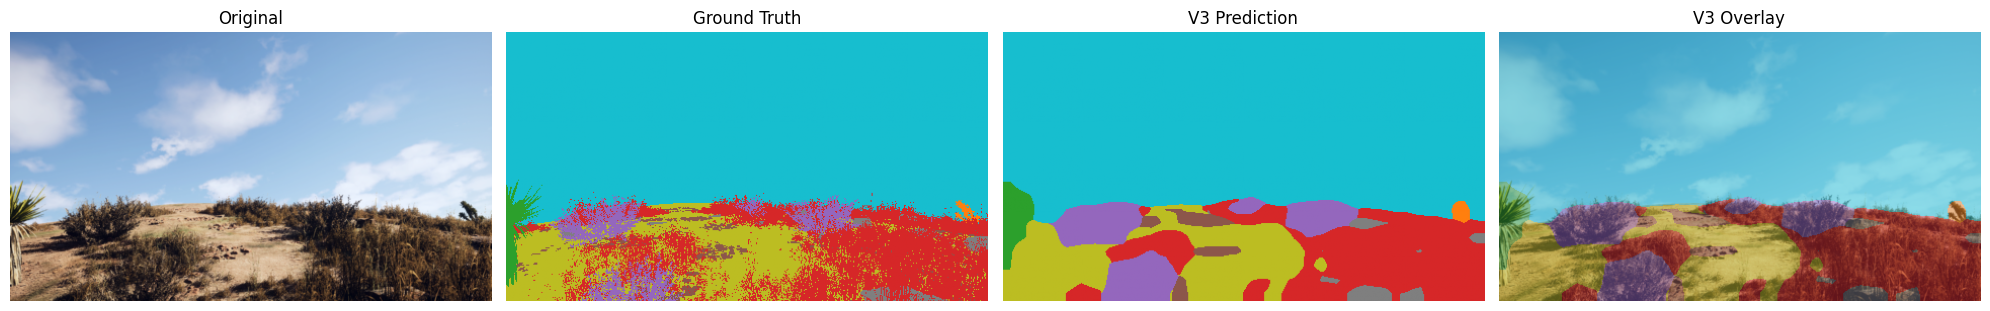

Ground truth classes:
['Trees', 'Lush Bushes', 'Dry Grass', 'Dry Bushes', 'Ground Clutter', 'Rocks', 'Landscape', 'Sky']

Predicted classes:
['Trees', 'Lush Bushes', 'Dry Grass', 'Dry Bushes', 'Ground Clutter', 'Rocks', 'Landscape', 'Sky']
------------------------------------------------------------
Sample 2/5
Dataset index: 12


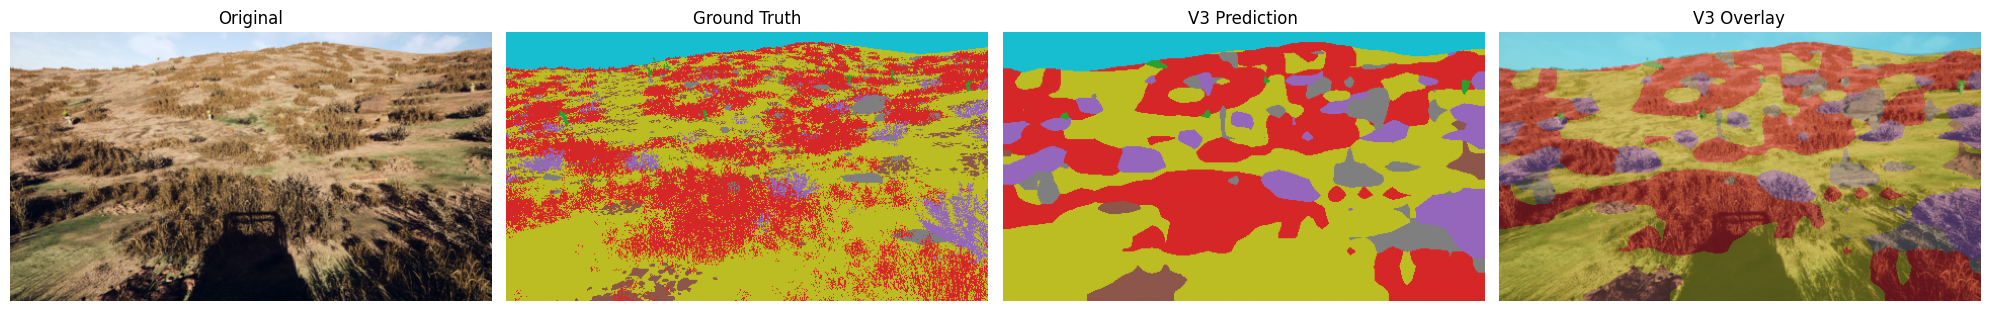

Ground truth classes:
['Lush Bushes', 'Dry Grass', 'Dry Bushes', 'Ground Clutter', 'Rocks', 'Landscape', 'Sky']

Predicted classes:
['Lush Bushes', 'Dry Grass', 'Dry Bushes', 'Ground Clutter', 'Rocks', 'Landscape', 'Sky']
------------------------------------------------------------
Sample 3/5
Dataset index: 140


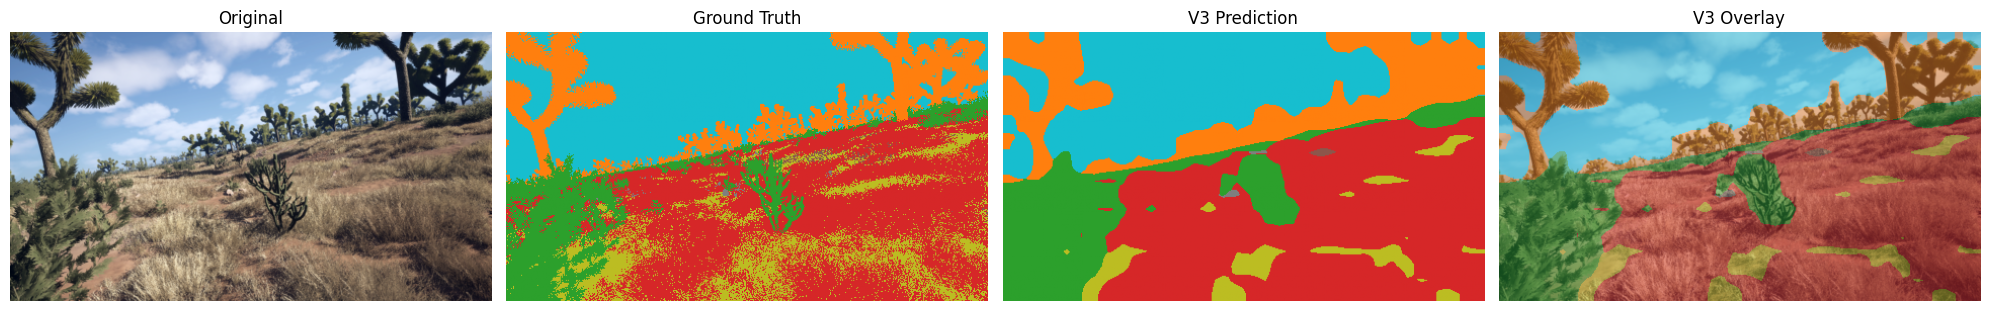

Ground truth classes:
['Trees', 'Lush Bushes', 'Dry Grass', 'Ground Clutter', 'Rocks', 'Landscape', 'Sky']

Predicted classes:
['Trees', 'Lush Bushes', 'Dry Grass', 'Ground Clutter', 'Rocks', 'Landscape', 'Sky']
------------------------------------------------------------
Sample 4/5
Dataset index: 125


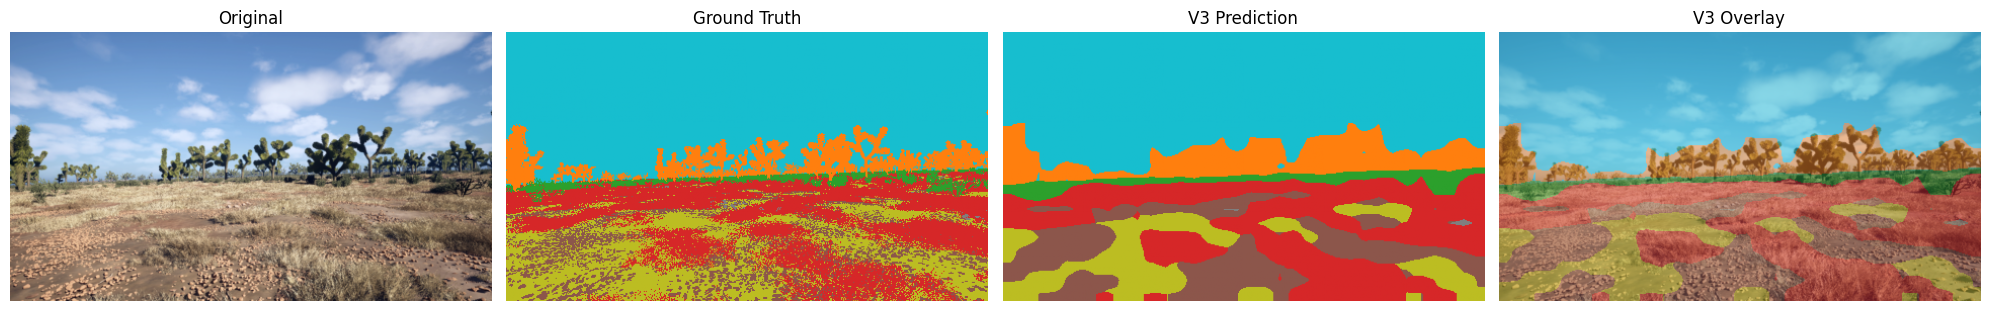

Ground truth classes:
['Trees', 'Lush Bushes', 'Dry Grass', 'Ground Clutter', 'Rocks', 'Landscape', 'Sky']

Predicted classes:
['Trees', 'Lush Bushes', 'Dry Grass', 'Ground Clutter', 'Rocks', 'Landscape', 'Sky']
------------------------------------------------------------
Sample 5/5
Dataset index: 114


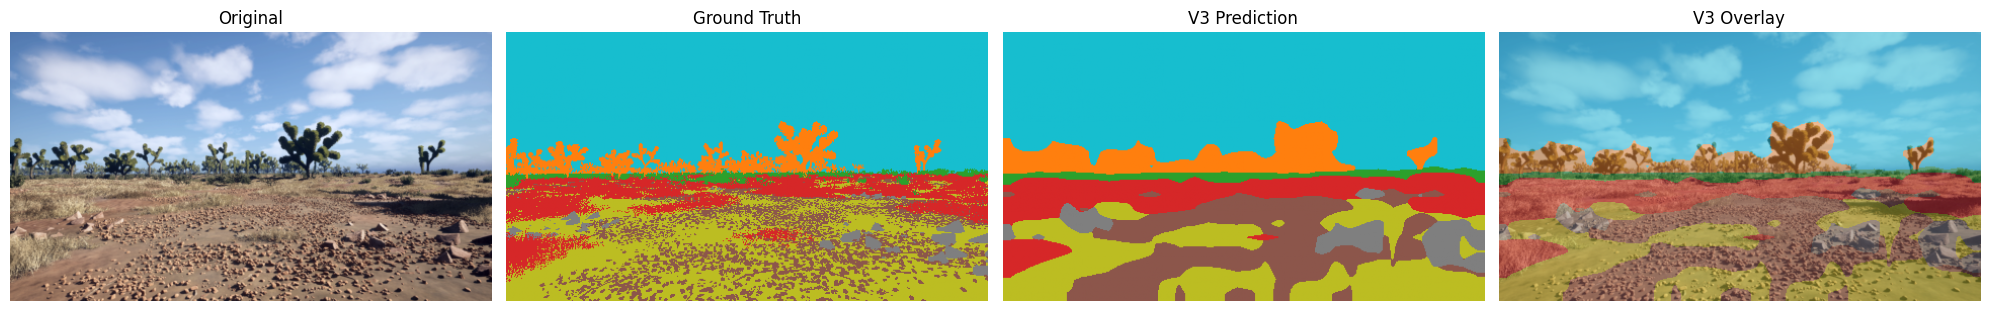

Ground truth classes:
['Trees', 'Lush Bushes', 'Dry Grass', 'Ground Clutter', 'Rocks', 'Landscape', 'Sky']

Predicted classes:
['Trees', 'Lush Bushes', 'Dry Grass', 'Ground Clutter', 'Rocks', 'Landscape', 'Sky']
------------------------------------------------------------
✅ VISUALIZATION COMPLETE


In [20]:
# ============================================================
# ROVER V3 — VISUAL PREDICTION CHECK
# ============================================================

import torch
import matplotlib.pyplot as plt
import numpy as np
import random

print("=" * 60)
print("ROVER V3 — VISUALIZATION")
print("=" * 60)

# ------------------------------------------------------------
# Make sure the best V3 checkpoint is loaded
# ------------------------------------------------------------

BEST_MODEL_PATH = (
    "/content/drive/MyDrive/"
    "Rover_Project/rover_v3_checkpoints/"
    "best_rover_v3_segmentation_head.pth"
)

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=device
)

# Handle either raw state_dict or wrapped checkpoint
if isinstance(checkpoint, dict) and "state_dict" in checkpoint:
    checkpoint = checkpoint["state_dict"]

classifier.load_state_dict(checkpoint)
classifier = classifier.to(device)
classifier.eval()

dino = dino.to(device)
dino.eval()

print("✅ V3 checkpoint loaded")
print("Device:", device)

# ------------------------------------------------------------
# Class names
# ------------------------------------------------------------

CLASS_NAMES = [
    "Background",
    "Trees",
    "Lush Bushes",
    "Dry Grass",
    "Dry Bushes",
    "Ground Clutter",
    "Logs",
    "Rocks",
    "Landscape",
    "Sky"
]

# ------------------------------------------------------------
# Visualization helper
# ------------------------------------------------------------

def visualize_v3_sample(dataset, index):

    # Dataset returns image, mask, metadata
    image, mask, metadata = dataset[index]

    # Add batch dimension
    image_batch = image.unsqueeze(0).to(device)

    # --------------------------------------------------------
    # Inference
    # --------------------------------------------------------

    with torch.no_grad():

        patch_features = dino.forward_features(
            image_batch
        )["x_norm_patchtokens"]

        logits_low = classifier(
            patch_features
        )

        logits = torch.nn.functional.interpolate(
            logits_low,
            size=(INPUT_H, INPUT_W),
            mode="bilinear",
            align_corners=False
        )

        prediction = torch.argmax(
            logits,
            dim=1
        )[0]

    prediction = prediction.cpu().numpy()
    mask = mask.cpu().numpy()

    # --------------------------------------------------------
    # Convert image for display
    # --------------------------------------------------------

    img = image.cpu().numpy()
    img = np.transpose(img, (1, 2, 0))

    # If normalized, try to bring it back to display range
    img = img - img.min()
    if img.max() > 0:
        img = img / img.max()

    # --------------------------------------------------------
    # Create overlay
    # --------------------------------------------------------

    # Simple class-color visualization
    cmap = plt.cm.get_cmap("tab10", NUM_CLASSES)

    pred_rgb = cmap(prediction)[..., :3]
    gt_rgb = cmap(mask)[..., :3]

    overlay = (
        0.55 * img +
        0.45 * pred_rgb
    )

    overlay = np.clip(
        overlay,
        0,
        1
    )

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    fig, axes = plt.subplots(
        1,
        4,
        figsize=(20, 5)
    )

    axes[0].imshow(img)
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(gt_rgb)
    axes[1].set_title("Ground Truth")
    axes[1].axis("off")

    axes[2].imshow(pred_rgb)
    axes[2].set_title("V3 Prediction")
    axes[2].axis("off")

    axes[3].imshow(overlay)
    axes[3].set_title("V3 Overlay")
    axes[3].axis("off")

    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # Classes present
    # --------------------------------------------------------

    gt_classes = np.unique(mask)
    pred_classes = np.unique(prediction)

    print("Ground truth classes:")
    print([
        CLASS_NAMES[int(x)]
        for x in gt_classes
        if int(x) < len(CLASS_NAMES)
    ])

    print()

    print("Predicted classes:")
    print([
        CLASS_NAMES[int(x)]
        for x in pred_classes
        if int(x) < len(CLASS_NAMES)
    ])

    print("-" * 60)


# ============================================================
# SHOW RANDOM VALIDATION SAMPLES
# ============================================================

NUM_SAMPLES = 5

print()
print(f"Showing {NUM_SAMPLES} validation samples...")
print()

for i in range(NUM_SAMPLES):

    index = random.randrange(
        len(val_dataset)
    )

    print(f"Sample {i + 1}/{NUM_SAMPLES}")
    print(f"Dataset index: {index}")

    visualize_v3_sample(
        val_dataset,
        index
    )

print("=" * 60)
print("✅ VISUALIZATION COMPLETE")
print("=" * 60)

In [21]:
from google.colab import files

files.download(
    "/content/drive/MyDrive/Rover_Project/rover_v3_checkpoints/best_rover_v3_segmentation_head.pth"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>